# Seznam — Predicción mensual del gasto publicitario

## Objetivo

Este notebook contiene exclusivamente la **fase de Machine Learning** del proyecto.

La preparación de datos y el *feature engineering* se realizan previamente en **PostgreSQL**, donde las tablas originales de Seznam (`client`, `probehnuto` y `dobito`) se transforman en una unidad analítica de:

> **1 cliente × 1 mes**

El objetivo es predecir el **gasto publicitario del mes siguiente** a partir de la información histórica disponible antes de ese mes.

La arquitectura final del proyecto separa claramente las responsabilidades:

**PostgreSQL → preparación temporal y construcción de variables → Python → preprocesamiento ML → modelo → evaluación**

Esta separación evita duplicar transformaciones y permite que SQL gestione las operaciones relacionales y temporales, mientras Python se centra en el modelado estadístico y la evaluación.


## 1. Datos preparados en PostgreSQL

El pipeline SQL genera dos conjuntos:

- `train`: observaciones anteriores a enero de 2015.
- `test`: observaciones desde enero de 2015.

La división es temporal, no aleatoria. Esto reproduce el escenario real de predicción: el modelo aprende del pasado y se evalúa sobre meses posteriores.

Entre las variables generadas en SQL se incluyen:

- retardos de gasto de 1 a 12 meses;
- medias, medianas, desviaciones y máximos históricos;
- cambios y ratios temporales;
- gasto desglosado por servicio;
- cuotas y concentración de servicios;
- historial de recargas de la cartera;
- dinámica de las recargas;
- estacionalidad;
- región y sector.

Por tanto, **este notebook no vuelve a construir estas variables**. Las consume tal y como salen del pipeline SQL.


In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 56
BASE_DIR = Path(".")

train = pd.read_csv(BASE_DIR / "train.csv")
test = pd.read_csv(BASE_DIR / "test.csv")

train["mes"] = pd.to_datetime(train["mes"])
test["mes"] = pd.to_datetime(test["mes"])

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")


Train: (563972, 91)
Test:  (362834, 91)


## 2. Comprobaciones iniciales

Antes de entrenar, se comprueba que la estructura recibida desde SQL es coherente con el problema temporal.

La variable objetivo es `gasto_publicitario`. Para cada observación, esta variable representa el gasto real del cliente durante el mes que queremos predecir.

Las variables `gasto_lag_*`, recargas, servicios y demás históricos corresponden exclusivamente a meses anteriores al objetivo.

Esta separación temporal es fundamental: si una variable utilizara información del propio mes objetivo, el modelo estaría recibiendo información que no existiría en el momento real de realizar la predicción.


In [12]:
objetivo = "gasto_publicitario"

print("Rango temporal train:", train["mes"].min(), "->", train["mes"].max())
print("Rango temporal test: ", test["mes"].min(), "->", test["mes"].max())
print("\nNulos en objetivo:")
print("train:", train[objetivo].isna().sum())
print("test: ", test[objetivo].isna().sum())


Rango temporal train: 2013-08-01 00:00:00 -> 2014-12-01 00:00:00
Rango temporal test:  2015-01-01 00:00:00 -> 2015-10-01 00:00:00

Nulos en objetivo:
train: 0
test:  0


## 3. Construcción de la matriz de modelización

El objetivo es mantener en Python únicamente las variables utilizadas por el modelo final.

No se incorporan automáticamente todas las columnas disponibles en `train`: variables como `año`, `mes_num`, `trimestre` o identificadores sirven para estructurar, analizar o validar los datos, pero no forman parte del conjunto predictivo del modelo final bloqueado.

La variable `gasto_publicitario` se mantiene separada como objetivo.

El identificador del cliente tampoco se utiliza como predictor: sería una identificación nominal del cliente y no una característica generalizable de su comportamiento.


In [18]:
features = [
    # Historial de gasto
    "gasto_mes_anterior", "gasto_lag_2", "gasto_lag_3",
    "gasto_lag_4", "gasto_lag_5", "gasto_lag_6",
    "gasto_lag_7", "gasto_lag_8", "gasto_lag_9",
    "gasto_lag_10", "gasto_lag_11", "gasto_lag_12",
    "gasto_media_3m", "gasto_media_6m", "gasto_media_12m",
    "gasto_mediana_12m", "gasto_std_3m", "gasto_std_6m",
    "gasto_std_12m", "gasto_max_12m", "num_meses_activos_12m",

    # Dinámica del gasto
    "cambio_1m", "cambio_2m", "ratio_lag1_media3",
    "cambio_12m", "ratio_lag1_lag12",
    "diferencia_media3_media12", "peso_3m_sobre_12m",
    "proporcion_meses_activos_3m_12m",

    # Servicios
    "gasto_servicio_1", "gasto_servicio_2", "gasto_servicio_3",
    "gasto_servicio_4", "gasto_servicio_5", "gasto_servicio_6",
    "gasto_servicio_7", "gasto_servicio_8", "gasto_servicio_9",
    "servicios_activos_lag1", "concentracion_servicios_lag1",
    "servicio_principal_share_lag1",
    "share_servicio_1", "share_servicio_2", "share_servicio_3",
    "share_servicio_4", "share_servicio_5", "share_servicio_6",
    "share_servicio_7", "share_servicio_8", "share_servicio_9",
    "ajustes_negativos_lag1", "num_ajustes_negativos_lag1",

    # Recargas
    "recarga_mes_anterior", "recarga_lag_2", "recarga_lag_3",
    "recarga_lag_4", "recarga_lag_5", "recarga_lag_6",
    "recarga_lag_7", "recarga_lag_8", "recarga_lag_9",
    "recarga_lag_10", "recarga_lag_11", "recarga_lag_12",
    "recarga_positiva_lag1", "ajuste_negativo_lag1",
    "recarga_ultimos_3_meses", "recarga_media_3m",
    "recarga_std_3m", "recarga_media_12m", "recarga_std_12m",
    "recarga_total_12m", "meses_recarga_positiva_12m",
    "ajustes_negativos_12m", "meses_con_ajuste_12m",
    "cambio_recarga_1m", "ratio_recarga_lag1_media3",
    "peso_recarga_3m_12m", "proporcion_meses_recarga_3m_12m",

    # Estacionalidad y perfil
    "mes_sin", "mes_cos",
    "region", "sector"
]

features = list(dict.fromkeys(features))

faltantes_train = sorted(set(features) - set(train.columns))
faltantes_test = sorted(set(features) - set(test.columns))

print("Variables predictivas:", len(features))
print("Variables ausentes en train:", faltantes_train)
print("Variables ausentes en test:", faltantes_test)


Variables predictivas: 83
Variables ausentes en train: []
Variables ausentes en test: []


## 4. Variable objetivo y estrategia de predicción

El objetivo es estimar el gasto publicitario del cliente en el mes siguiente.

En lugar de aprender directamente el nivel completo de gasto, el modelo final aprende el **cambio respecto al mes anterior**:

`cambio = gasto_publicitario - gasto_mes_anterior`

Después, la predicción se reconstruye como:

`gasto_predicho = gasto_mes_anterior + cambio_predicho`

Esta formulación aprovecha la fuerte continuidad temporal del gasto. El modelo no necesita aprender desde cero cuál es el nivel habitual de cada cliente; utiliza el último gasto observado como punto de partida y aprende qué factores explican que el siguiente mes aumente o disminuya.

La elección resulta especialmente adecuada para este problema porque una gran parte del comportamiento futuro está relacionada con la trayectoria reciente del propio cliente.


In [19]:
X_train_model = train[features].copy()
X_test_model = test[features].copy()

y_train_target = train[objetivo].copy()
y_test_target = test[objetivo].copy()

# El cambio mensual es el objetivo que aprende el modelo.
y_train_change = y_train_target - train["gasto_mes_anterior"]


## 5. Preprocesamiento

Las variables numéricas se imputan utilizando únicamente información del conjunto de entrenamiento y las variables categóricas se codifican mediante *one-hot encoding*.

La imputación basada exclusivamente en `train` evita que las características de `test` influyan en la preparación del modelo.

`region` y `sector` se mantienen como variables categóricas porque representan perfiles estructurales de los clientes que no deben tratarse como números con un orden artificial.


In [20]:
categorical_features = ["region", "sector"]
numeric_features = [c for c in features if c not in categorical_features]

numeric_pipeline = SimpleImputer(strategy="median")

categorical_pipeline = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop"
)

X_train_prepared = preprocessor.fit_transform(X_train_model)
X_test_prepared = preprocessor.transform(X_test_model)

print("Matriz train:", X_train_prepared.shape)
print("Matriz test: ", X_test_prepared.shape)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['peso_recarga_3m_12m']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['peso_recarga_3m_12m']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Matriz train: (563972, 148)
Matriz test:  (362834, 148)


## 6. Modelo final

El modelo seleccionado es `HistGradientBoostingRegressor` con pérdida absoluta.

La configuración se mantiene fija para reproducir el modelo final del proyecto. La selección de hiperparámetros se realizó previamente mediante una etapa temporal de desarrollo y no se repite aquí.

La semilla se fija en **56** para garantizar la reproducibilidad del entrenamiento.


In [21]:
modelo_final = HistGradientBoostingRegressor(
    loss="absolute_error",
    learning_rate=0.025,
    max_iter=600,
    max_leaf_nodes=63,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=RANDOM_STATE
)

modelo_final.fit(X_train_prepared, y_train_change)


HistGradientBoostingRegressor(l2_regularization=1.0, learning_rate=0.025,
                              loss='absolute_error', max_iter=600,
                              max_leaf_nodes=63, random_state=56)

## 7. Evaluación temporal

Las predicciones se reconstruyen añadiendo el cambio estimado al gasto del mes anterior.

La evaluación se realiza sobre la ventana temporal de 2015. Es importante interpretar esta ventana como una **evaluación temporal confirmatoria**, ya que fue inspeccionada durante el desarrollo del proyecto y, por tanto, no constituye un *holdout* completamente intocado.

El benchmark de referencia es el gasto del mes anterior. No se utiliza para presentar el modelo como perfecto, sino para cuantificar cuánto valor adicional aporta la modelización respecto a una estrategia sencilla de persistencia.


In [22]:
delta_pred = modelo_final.predict(X_test_prepared)

pred_final = (
    test["gasto_mes_anterior"].to_numpy()
    + delta_pred
)

mae = mean_absolute_error(y_test_target, pred_final)
rmse = mean_squared_error(y_test_target, pred_final) ** 0.5
r2 = r2_score(y_test_target, pred_final)

error_absoluto = np.abs(y_test_target.to_numpy() - pred_final)
mediana_error = np.median(error_absoluto)

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:,.2f} Kč")
print(f"RMSE: {rmse:,.2f} Kč")
print(f"Mediana del error absoluto: {mediana_error:,.2f} Kč")
print(f"Mediana del error absoluto: {mediana_error / 24.3:,.2f} € aprox.")


R²: 0.8655
MAE: 2,778.42 Kč
RMSE: 18,625.90 Kč
Mediana del error absoluto: 386.49 Kč
Mediana del error absoluto: 15.91 € aprox.


## 8. Resultados

La ejecución final del modelo produce los siguientes resultados sobre el conjunto de prueba temporal:

* R² = 0,8655
* MAE = 2.778,42 Kč
* RMSE = 18.625,90 Kč
* Mediana del error absoluto = 386,49 Kč ≈ 15,91 €

La mediana del error absoluto permite interpretar el error de una predicción típica: aproximadamente la mitad de las predicciones presentan un error absoluto inferior a 386 Kč (≈ 15,91 €).

El RMSE es superior al MAE, lo que indica que existen algunas observaciones con errores considerablemente mayores que los habituales. Esto es consistente con una variable económica en la que determinados clientes pueden experimentar cambios bruscos en su inversión publicitaria entre meses.

En conjunto, los resultados muestran que el modelo captura una parte importante de la variabilidad del gasto publicitario y mantiene errores relativamente reducidos para una proporción considerable de las observaciones, aunque las predicciones son menos precisas en aquellos casos caracterizados por cambios de gasto especialmente elevados.


In [23]:
test_resultados = test[["id_cliente", "mes", "gasto_publicitario", "gasto_mes_anterior"]].copy()
test_resultados["prediccion"] = pred_final
test_resultados["error"] = (
    test_resultados["gasto_publicitario"] - test_resultados["prediccion"]
)
test_resultados["error_absoluto"] = test_resultados["error"].abs()

test_resultados.head()


,id_cliente,mes,gasto_publicitario,gasto_mes_anterior,prediccion,error,error_absoluto
0,977272,2015-04-01,1478.94,0.0,1832.019705,-353.079705,353.079705
1,8887,2015-03-01,3108.60,0.0,508.333744,2600.266256,2600.266256
2,68376,2015-02-01,866.64,0.0,970.272183,-103.632183,103.632183
3,965231,2015-07-01,169.56,0.0,71.559324,98.000676,98.000676
4,9779904,2015-08-01,15.70,0.0,320.960476,-305.260476,305.260476


## 9. Comportamiento mensual

Además de las métricas individuales, resulta útil comprobar si el modelo reproduce razonablemente la evolución agregada del gasto publicitario.

Esta perspectiva tiene interés empresarial: una predicción puede presentar errores individuales en determinados clientes y, al mismo tiempo, proporcionar una estimación útil de la evolución global de la inversión publicitaria.


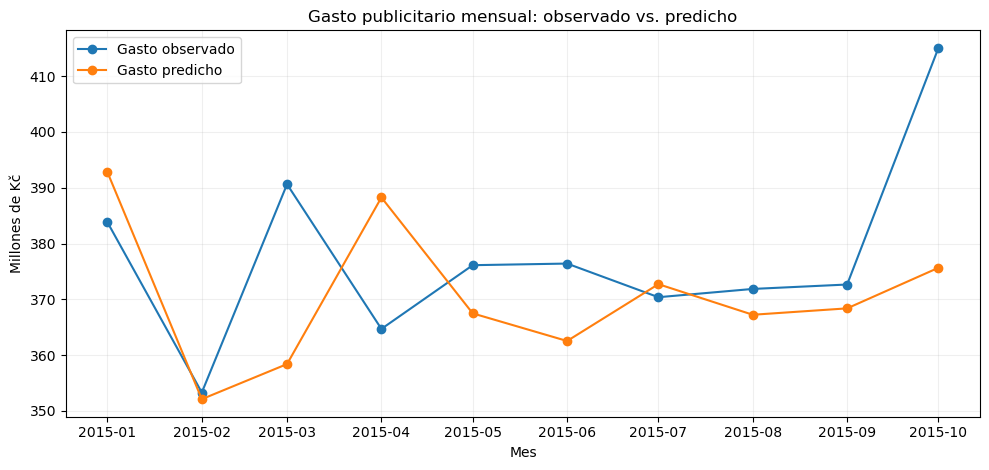

In [24]:
mensual = (
    test_resultados
    .groupby("mes", as_index=False)
    .agg(
        gasto_observado=("gasto_publicitario", "sum"),
        gasto_predicho=("prediccion", "sum"),
        error_mediano=("error_absoluto", "median"),
        mae=("error_absoluto", "mean")
    )
)

fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    mensual["mes"],
    mensual["gasto_observado"] / 1e6,
    marker="o",
    label="Gasto observado"
)

ax.plot(
    mensual["mes"],
    mensual["gasto_predicho"] / 1e6,
    marker="o",
    label="Gasto predicho"
)

ax.set_title("Gasto publicitario mensual: observado vs. predicho")
ax.set_ylabel("Millones de Kč")
ax.set_xlabel("Mes")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


## 10. Observado frente a predicho

La relación entre gasto observado y predicho permite comprobar si el modelo mantiene coherencia en diferentes escalas de inversión.

Debido a la fuerte asimetría del gasto, la escala logarítmica facilita visualizar simultáneamente clientes con inversiones pequeñas y clientes con inversiones muy elevadas.

La diagonal representa el caso ideal: cuanto más cerca se encuentra una observación de esa línea, menor es su error de predicción.


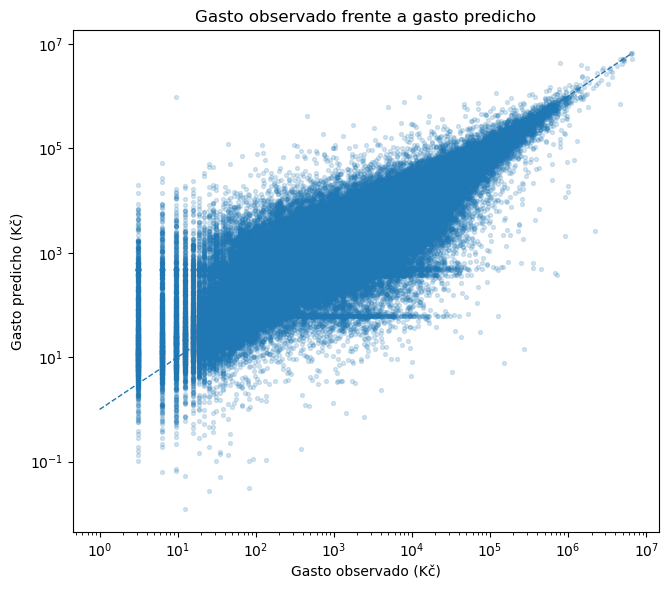

In [25]:
fig, ax = plt.subplots(figsize=(6.8, 6))

actual = test_resultados["gasto_publicitario"].to_numpy()
pred = test_resultados["prediccion"].to_numpy()

mask = (actual > 0) & (pred > 0)

ax.scatter(
    actual[mask],
    pred[mask],
    s=8,
    alpha=0.18
)

limite = max(actual[mask].max(), pred[mask].max())

ax.plot(
    [1, limite],
    [1, limite],
    linestyle="--",
    linewidth=1
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Gasto observado (Kč)")
ax.set_ylabel("Gasto predicho (Kč)")
ax.set_title("Gasto observado frente a gasto predicho")

plt.tight_layout()
plt.show()


## 11. Interpretación final

El proyecto muestra que el historial de comportamiento del cliente contiene una cantidad considerable de información para anticipar su gasto publicitario del mes siguiente.

El valor del modelo no procede únicamente del algoritmo utilizado. Una parte fundamental del resultado está en la representación temporal construida previamente en PostgreSQL: los retardos respetan el calendario, los meses sin actividad se representan correctamente, los históricos de gasto y recargas no incorporan información futura y la composición por servicios añade información sobre la estructura de la inversión.

La predicción mediante cambios respecto al mes anterior también resulta coherente con la naturaleza del problema. En lugar de aprender de nuevo el nivel absoluto de cada cliente, el modelo parte de su comportamiento reciente y aprende qué señales están asociadas a aumentos o disminuciones.

El R² de 0,8853 indica una capacidad elevada para explicar la variabilidad observada en esta ventana temporal. La mediana del error absoluto, cercana a 53 €, ofrece además una perspectiva complementaria sobre el comportamiento de una observación típica.

Sin embargo, el modelo no puede anticipar de forma fiable todos los cambios extraordinarios. Los mayores errores aparecen cuando un cliente modifica bruscamente su inversión entre dos meses. Este tipo de movimientos puede estar provocado por decisiones comerciales, campañas puntuales u otros factores que no aparecen en las variables históricas disponibles.

Por ello, el principal límite del proyecto no debe interpretarse únicamente como una limitación del algoritmo. También refleja la información disponible. Para mejorar la capacidad de anticipar cambios estructurales sería necesario incorporar nuevas señales relacionadas con campañas, eventos comerciales, cambios de estrategia o factores externos.

Desde una perspectiva de negocio, el modelo puede entenderse como una herramienta para **anticipar la evolución de la inversión publicitaria**, tanto a nivel de cliente como agregada. Sus predicciones podrían utilizarse como apoyo para planificación comercial, estimación de volumen publicitario y detección de clientes cuyo comportamiento esperado se desvía significativamente de su trayectoria histórica.


## 12. Limitaciones metodológicas

- La ventana de 2015 es una **evaluación temporal confirmatoria**, no un *holdout* completamente intocado.
- La variable objetivo presenta una distribución muy asimétrica y algunos cambios de magnitud extraordinaria.
- El modelo utiliza principalmente información histórica y, por tanto, tiene una capacidad limitada para anticipar acontecimientos completamente nuevos.
- Las variables de servicio están anonimizadas; `gasto_servicio_1`–`gasto_servicio_9` representan categorías de servicio y no se interpretan semánticamente.
- La evaluación mide principalmente precisión predictiva; una futura ampliación podría incorporar análisis de estabilidad temporal, intervalos de predicción y evaluación sobre un periodo temporal completamente reservado.
